# 03 · Monthly bill audit & anomaly detection

**Question.** Which monthly utility bills look wrong or wasteful, how much do they cost, and what should a facility team check first?

**Data.** LL84 monthly electricity and gas (D2) for a **focus portfolio of 8 large-format stores**, chosen by rule rather than by hand, plus NYC monthly weather (D3). Audit window = the two most recent published years (2023–2024).

**Method.** Three layers, so no single test decides alone:
1. **Rules**: zero reads, spikes (> 3× rolling median), flatlines (estimated bills), sudden step changes.
2. **Weather-driven residuals**: each store's ASHRAE-14 change-point model gives an *expected* bill for that month's weather; |robust z| > 2.5 is flagged.
3. **CUSUM** on the standardised residuals catches slow drift that never trips a single-month threshold.

Every flag becomes a **facility ticket**: expected vs actual, excess kWh and $, a likely-cause heuristic and a priority. Prices are cited assumptions (EIA 2025 New York commercial averages).

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import Markdown, display

from wattwise import io, anomalies, viz

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(io.assumptions()["seed"])
pd.set_option("display.float_format", lambda v: f"{v:,.0f}")
pd.set_option("display.max_colwidth", 90)
viz.use_style()

A = io.assumptions()
P_ELEC = A["prices"]["electricity_usd_per_kwh"]["value"]
P_GAS_THERM = A["prices"]["natural_gas_usd_per_mcf"]["value"] / A["prices"]["natural_gas_therms_per_mcf"]["value"]
KBTU_PER_KWH = A["units"]["kbtu_per_kwh"]
print(f"Assumed prices: electricity ${P_ELEC:.4f}/kWh, gas ${P_GAS_THERM:.3f}/therm (EIA NY commercial 2025)")

annual = io.load("annual_clean")
monthly = io.load("monthly")
weather = io.load("weather_monthly")
AUDIT_YEARS = [2023, 2024]
HISTORY_YEARS = [2019, 2021, 2023, 2024]
MIN_GFA = A["thresholds"]["big_box_min_gfa_ft2"]

Assumed prices: electricity $0.2107/kWh, gas $1.107/therm (EIA NY commercial 2025)


## 1 · Selecting the focus portfolio (by rule)
Eligible = big-box type, ≥ 100,000 ft², data-quality score ≥ 95, complete electricity **and** gas bills for 2023–2024, complete electricity history in every published year since 2019 (needed for the forecasting backtest in notebook 04), and **electricity + gas cover ≥ 90% of the store's annual site energy**. That last rule excludes stores on district steam or other fuels, whose monthly bills would be incomplete. The 8 largest eligible stores form the focus portfolio. Names are anonymised.

In [2]:
latest = annual[(annual.cohort == "Big-box retail") & (annual.year == max(AUDIT_YEARS)) & (annual.gfa_ft2 >= MIN_GFA)]
win = monthly[monthly.year.isin(AUDIT_YEARS)]
cov = win.groupby("property_id").agg(elec_months=("elec_kwh", lambda x: int((x > 0).sum())),
                                     gas_months=("gas_kbtu", lambda x: int((x > 0).sum()))).reset_index()
hist = monthly[monthly.year.isin(HISTORY_YEARS)].groupby("property_id").elec_kwh.apply(lambda x: int((x > 0).sum())).rename("history_months")
cand = latest.merge(cov, on="property_id").merge(hist, on="property_id", how="left")
cand["bill_coverage"] = (cand.elec_kwh * KBTU_PER_KWH + cand.gas_kbtu.fillna(0)) / (cand.site_eui * cand.gfa_ft2)
cand["eligible"] = ((cand.dq_score >= 95) & (cand.elec_months == 24) & (cand.gas_months == 24)
                    & (cand.history_months == 12 * len(HISTORY_YEARS)) & (cand.bill_coverage >= 0.9))
print(f"Large big-box stores in {max(AUDIT_YEARS)}: {len(cand)} | complete 24-month electricity: {(cand.elec_months == 24).sum()} | fully eligible: {cand.eligible.sum()}")
focus = cand[cand.eligible].sort_values("gfa_ft2", ascending=False).head(8).reset_index(drop=True)
focus["store"] = [f"Store {chr(65 + i)}" for i in range(len(focus))]
focus_view = focus[["store", "property_type", "gfa_m2", "site_eui_kwh_m2", "elec_share", "dq_score"]].copy()
focus_view["elec_share"] = (focus_view.elec_share * 100).round(0)
focus_view.rename(columns={"elec_share": "electricity % of energy"})

Large big-box stores in 2024: 92 | complete 24-month electricity: 69 | fully eligible: 18


,store,property_type,gfa_m2,site_eui_kwh_m2,electricity % of energy,dq_score
0,Store A,Retail Store,"50,778",185,83,100
1,Store B,Wholesale Club/Supercenter,"32,198",118,39,98
2,Store C,Retail Store,"20,716",149,99,100
3,Store D,Retail Store,"18,872",252,43,100
4,Store E,Wholesale Club/Supercenter,"18,551",225,60,96
5,Store F,Retail Store,"15,452",141,75,100
6,Store G,Wholesale Club/Supercenter,"14,807",168,69,100
7,Store H,Retail Store,"13,837",229,62,100


In [3]:
name = dict(zip(focus.property_id, focus.store))
gfa_m2 = dict(zip(focus.store, focus.gfa_m2))
bills = monthly[monthly.property_id.isin(name) & monthly.year.isin(AUDIT_YEARS)].copy()
bills["store"] = bills.property_id.map(name)
bills["elec_cost_usd"] = bills.elec_kwh * P_ELEC
bills["gas_cost_usd"] = bills.gas_therms * P_GAS_THERM
bills["total_cost_usd"] = bills.elec_cost_usd + bills.gas_cost_usd
bills["cost_usd_per_m2"] = bills.total_cost_usd / bills.store.map(gfa_m2)
bill_summary = bills.groupby("store").agg(
    kwh_per_yr=("elec_kwh", lambda s: s.sum() / len(AUDIT_YEARS)),
    therms_per_yr=("gas_therms", lambda s: s.sum() / len(AUDIT_YEARS)),
    cost_usd_per_yr=("total_cost_usd", lambda s: s.sum() / len(AUDIT_YEARS)),
    cost_usd_per_m2_yr=("cost_usd_per_m2", lambda s: s.sum() / len(AUDIT_YEARS)),
)
bill_summary["electricity_share_of_cost"] = (bills.groupby("store").elec_cost_usd.sum() / bills.groupby("store").total_cost_usd.sum() * 100)
bill_summary.loc["Portfolio"] = [bill_summary.kwh_per_yr.sum(), bill_summary.therms_per_yr.sum(), bill_summary.cost_usd_per_yr.sum(),
                                 bill_summary.cost_usd_per_yr.sum() / sum(gfa_m2.values()),
                                 bills.elec_cost_usd.sum() / bills.total_cost_usd.sum() * 100]
print("Estimated annual utility spend (assumption-based prices), average of 2023–2024:")
bill_summary

Estimated annual utility spend (assumption-based prices), average of 2023–2024:


,kwh_per_yr,therms_per_yr,cost_usd_per_yr,cost_usd_per_m2_yr,electricity_share_of_cost
store,,,,,
Store A,"7,247,523","54,159","1,587,015",31,96
Store B,"1,816,763","83,060","474,751",15,81
Store C,"2,973,432",603,"627,170",30,100
Store D,"2,055,709","90,897","533,774",28,81
Store E,"2,757,299","54,412","641,204",35,91
Store F,"1,635,842","18,522","365,179",24,94
Store G,"1,585,197","23,966","360,535",24,93
Store H,"2,082,813","41,576","484,879",35,91
Portfolio,"22,154,578","367,195","5,074,507",27,92


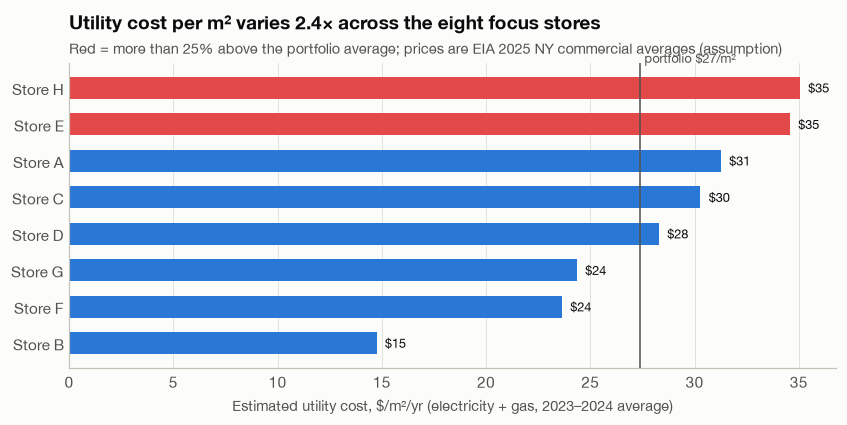

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.6))
cpm = bill_summary.drop("Portfolio").cost_usd_per_m2_yr.sort_values()
port = bill_summary.loc["Portfolio", "cost_usd_per_m2_yr"]
ax.barh(cpm.index, cpm.values, color=[viz.RED if v > port * 1.25 else viz.BLUE for v in cpm.values], height=0.6)
ax.axvline(port, color=viz.INK_2, linewidth=1)
ax.text(port, len(cpm) - 0.4, f" portfolio ${port:,.0f}/m²", fontsize=8.5, color=viz.INK_2, va="bottom")
for i, v in enumerate(cpm.values):
    ax.text(v + 0.4, i, f"${v:,.0f}", va="center", fontsize=8.5)
ax.set_xlabel("Estimated utility cost, $/m²/yr (electricity + gas, 2023–2024 average)")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
viz.title(ax, f"Utility cost per m² varies {cpm.max() / cpm.min():.1f}× across the eight focus stores",
          "Red = more than 25% above the portfolio average; prices are EIA 2025 NY commercial averages (assumption)")
viz.save(fig, "03_cost_per_m2")
plt.show()

## 2 · Running the three detection layers
Electricity is modelled against temperature (change-point). Gas is modelled the same way, where heating dominates.

In [5]:
all_flags, models, tix = [], {}, []
for pid, store in name.items():
    s = bills[bills.property_id == pid]
    for metric, col, unit, price, kwh_per_unit in [("electricity", "elec_kwh", "kWh", P_ELEC, 1.0),
                                                     ("gas", "gas_therms", "therms", P_GAS_THERM, 100 / KBTU_PER_KWH)]:
        f, mdl = anomalies.detect(s, col, weather)
        f["store"], f["metric"] = store, metric
        all_flags.append(f)
        models[(store, metric)] = mdl
        t = anomalies.tickets(f, store, metric, unit, price, kwh_per_unit)
        if len(t):
            tix.append(t)
flags = pd.concat(all_flags, ignore_index=True)
tickets = pd.concat(tix, ignore_index=True).sort_values(["at_stake_usd", "store"], ascending=[False, True]).reset_index(drop=True)

layer_counts = pd.DataFrame({
    "rule: zero": flags.groupby("metric").rule_zero.sum(),
    "rule: spike": flags.groupby("metric").rule_spike.sum(),
    "rule: flatline": flags.groupby("metric").rule_flatline.sum(),
    "rule: step": flags.groupby("metric").rule_step.sum(),
    "residual |z|>2.5": flags.groupby("metric").flag_resid.sum(),
    "CUSUM drift runs": flags.groupby(["metric", "store"]).cusum_run.max().groupby("metric").sum(),
    "store-months audited": flags.groupby("metric").size(),
})
layer_counts

,rule: zero,rule: spike,rule: flatline,rule: step,residual |z|>2.5,CUSUM drift runs,store-months audited
metric,,,,,,,
electricity,0,1,0,5,14,3,192
gas,0,9,0,8,20,3,192


In [6]:
fit_table = pd.DataFrame([
    {"store": s, "metric": m, "model": mdl.kind, "adj R²": mdl.adj_r2, "CV(RMSE) %": mdl.cvrmse * 100, "NMBE %": mdl.nmbe * 100}
    for (s, m), mdl in models.items()
])
print("Expected-bill models (the 'normal' each month is compared against):")
fit_table.pivot(index="store", columns="metric", values=["model", "adj R²", "CV(RMSE) %"]).round(2)

Expected-bill models (the 'normal' each month is compared against):


model           adj R²      CV(RMSE) %    
metric  electricity  gas electricity gas electricity gas
store                                                   
Store A          5P  3PH           1   1           7  23
Store B         3PC  3PH           1   1          33  29
Store C         3PC   2P           1   0           6   9
Store D         3PC  3PH           1   1           3  11
Store E         3PH  3PH           0   1          21  12
Store F          5P  3PH           1   1           8  14
Store G         3PC  3PH           1   1           7  42
Store H          5P  3PH           1   1           4  12

## 3 · What the anomalies look like
Grey band = expected ± 2.5σ from the weather model. Orange dots = residual anomalies; red squares = rule hits; shaded = CUSUM drift alarm.

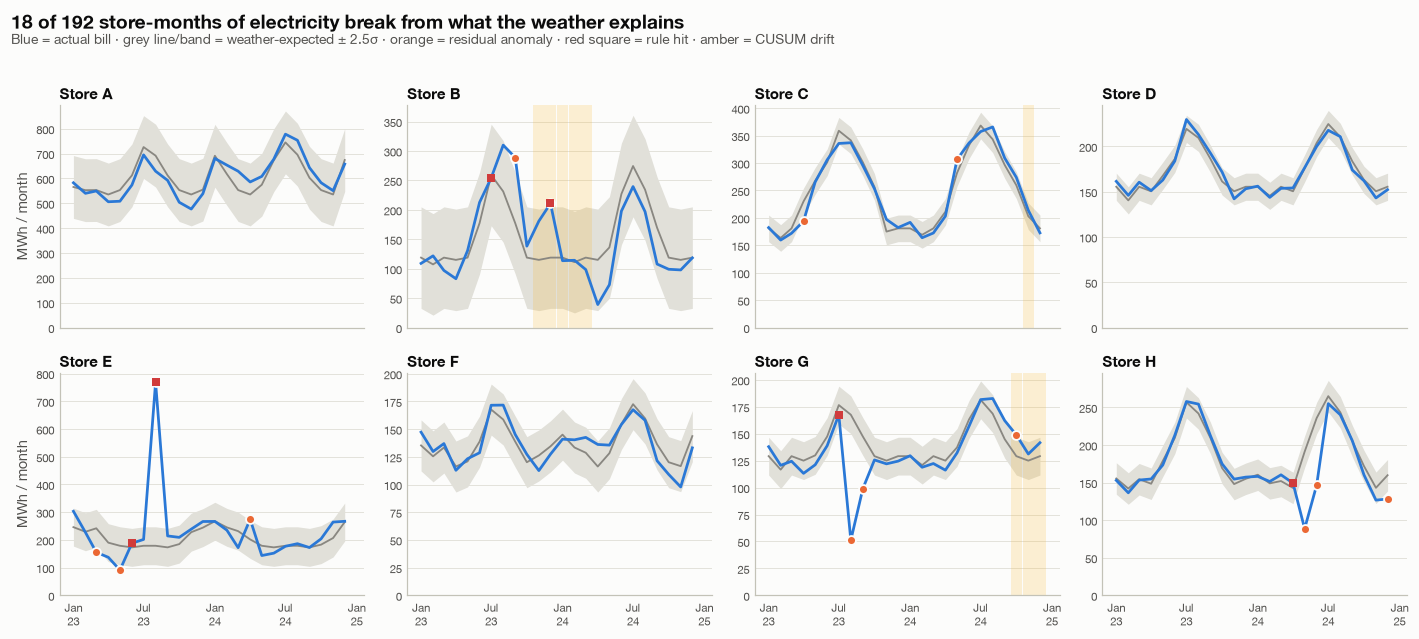

In [7]:
elec = flags[flags.metric == "electricity"]
stores = list(name.values())
fig, axes = plt.subplots(2, 4, figsize=(13, 5.6), sharex=True)
for ax, store in zip(axes.flat, stores):
    d = elec[elec.store == store]
    k = 1e3
    ax.fill_between(d.month, (d.expected - 2.5 * d.sigma) / k, (d.expected + 2.5 * d.sigma) / k, color=viz.GRID, linewidth=0)
    ax.plot(d.month, d.expected / k, color=viz.MUTED, linewidth=1.2)
    ax.plot(d.month, d.elec_kwh / k, color=viz.BLUE, linewidth=1.8)
    if d.flag_cusum.any():
        for mth in d.loc[d.flag_cusum, "month"]:
            ax.axvspan(mth - pd.Timedelta(days=15), mth + pd.Timedelta(days=15), color=viz.WARNING, alpha=0.18, linewidth=0)
    r = d[d.flag_resid]
    ax.scatter(r.month, r.elec_kwh / k, color=viz.ORANGE, s=34, zorder=4, edgecolor=viz.SURFACE, linewidth=1.2)
    rr = d[d.rule_spike | d.rule_zero | d.rule_flatline | d.rule_step]
    ax.scatter(rr.month, rr.elec_kwh / k, color=viz.CRITICAL, marker="s", s=22, zorder=5)
    ax.set_title(store, fontsize=10, pad=4)
    ax.set_ylim(0, None)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%y"))
    ax.tick_params(labelsize=7.5)
for ax in axes[:, 0]:
    ax.set_ylabel("MWh / month")
n_flag_months = int((elec.flag_resid | elec.rule_spike | elec.rule_zero | elec.rule_flatline | elec.rule_step).sum())
fig.suptitle(f"{n_flag_months} of {len(elec)} store-months of electricity break from what the weather explains",
             x=0.01, ha="left", fontsize=12.5, fontweight="bold", y=1.03)
fig.text(0.01, 0.975, "Blue = actual bill · grey line/band = weather-expected ± 2.5σ · orange = residual anomaly · red square = rule hit · amber = CUSUM drift",
         color=viz.INK_2, fontsize=9)
fig.tight_layout()
viz.save(fig, "03_anomaly_small_multiples")
plt.show()

## 4 · Facility tickets
One row per flagged store-month, plus one row per CUSUM drift run. Three ticket types:
* **Energy waste** (month or drift): consumption above what weather explains. This is the only type counted as *avoidable* kWh and $.
* **Billing / meter check**: spikes vs neighbours, zero reads, estimated (flat) bills, or bills far below expected. Money is at stake, but the cause is the data, not the building.
* **Level shift**: a sustained step change. Confirm the cause before calling it waste.

In [8]:
print(f"{len(tickets)} tickets | by type: {tickets.ticket_type.value_counts().to_dict()} | priority: {tickets.priority.value_counts().to_dict()}")
tickets.head(15)

59 tickets | by type: {'Billing / meter check': 25, 'Energy waste': 16, 'Level shift': 12, 'Energy waste (drift)': 6} | priority: {'High': 22, 'Low': 20, 'Medium': 17}


,store,month,metric,unit,ticket_type,expected,actual,avoidable_kwh,avoidable_usd,at_stake_usd,z,detected_by,likely_cause,priority
0,Store E,2023-08,electricity,kWh,Billing / meter check,178786,768368,0,0,124225,22,"rule:spike, residual z=+21.5","Spike vs neighbouring months: likely catch-up or mis-keyed bill, verify before paying",High
1,Store B,2023-11 → 2024-03,electricity,kWh,Energy waste (drift),582796,718198,69011,14541,33917,1,CUSUM (5 months),"Gradual upward drift: base-load creep (lighting, refrigeration, plant left on), degrad...",High
2,Store G,2023-08,electricity,kWh,Billing / meter check,167622,51143,0,0,24542,-17,residual z=-16.6,"Far below expected: partial closure, meter fault or under-billing, verify",High
3,Store B,2023-09,electricity,kWh,Energy waste,177383,288885,111502,23493,23493,3,residual z=+3.2,"Summer excess beyond weather: HVAC schedule, cooling setpoint or chiller efficiency",High
4,Store H,2024-05,electricity,kWh,Billing / meter check,191114,88644,0,0,21590,-12,residual z=-12.2,"Far below expected: partial closure, meter fault or under-billing, verify",High
5,Store B,2023-12,electricity,kWh,Energy waste,118860,210819,91960,19376,19376,3,"rule:step, residual z=+2.7","Winter electric excess: AHU fans / electric heat out of hours, extended holiday trading",High
6,Store H,2024-06,electricity,kWh,Billing / meter check,235825,146532,0,0,18814,-11,residual z=-10.7,"Far below expected: partial closure, meter fault or under-billing, verify",High
7,Store E,2023-05,electricity,kWh,Billing / meter check,178786,91196,0,0,18455,-3,residual z=-3.2,"Far below expected: partial closure, meter fault or under-billing, verify",High
8,Store E,2023-03,electricity,kWh,Billing / meter check,241828,155194,0,0,18254,-3,residual z=-3.2,"Far below expected: partial closure, meter fault or under-billing, verify",High
9,Store E,2024-04,electricity,kWh,Energy waste,201700,274367,72667,15311,15311,3,residual z=+2.7,"Shoulder-season excess: base load (lighting, refrigeration, after-hours plant)",High


In [9]:
billing_mask = tickets.ticket_type == "Billing / meter check"
avoid = tickets.groupby("store").agg(avoidable_kwh=("avoidable_kwh", "sum"), avoidable_usd=("avoidable_usd", "sum"), tickets=("store", "size"))
avoid["billing_to_verify_usd"] = tickets[billing_mask].groupby("store").at_stake_usd.sum()
avoid = avoid.reindex(stores).fillna(0)
avoid_kwh_yr = avoid.avoidable_kwh.sum() / len(AUDIT_YEARS)
avoid_usd_yr = avoid.avoidable_usd.sum() / len(AUDIT_YEARS)
billing_usd = tickets.loc[billing_mask, "at_stake_usd"].sum()
port_cost_yr = bill_summary.loc["Portfolio", "cost_usd_per_yr"]
print(f"Avoidable (high-side anomalies): {avoid_kwh_yr:,.0f} kWh/yr ≈ ${avoid_usd_yr:,.0f}/yr "
      f"= {avoid_usd_yr / port_cost_yr:.1%} of estimated focus-portfolio utility spend")
print(f"Billing / meter issues to verify (not counted as savings): ${billing_usd:,.0f} across {billing_mask.sum()} tickets")
avoid

Avoidable (high-side anomalies): 648,469 kWh/yr ≈ $60,710/yr = 1.2% of estimated focus-portfolio utility spend
Billing / meter issues to verify (not counted as savings): $278,787 across 25 tickets


,avoidable_kwh,avoidable_usd,tickets,billing_to_verify_usd
store,,,,
Store A,0,0,5,12426
Store B,672196,72510,10,3117
Store C,35941,7470,4,7600
Store D,83775,3165,2,2180
Store E,304251,24059,18,170767
Store F,109984,4155,5,394
Store G,38348,8079,9,34743
Store H,52443,1981,6,47560


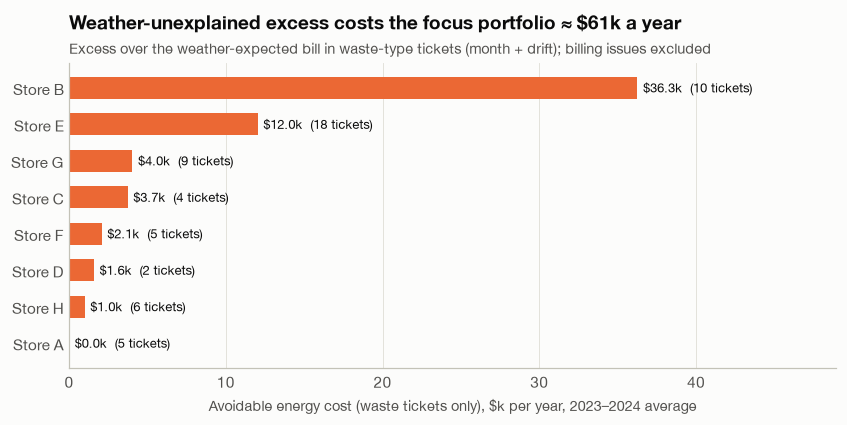

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.6))
av = avoid.sort_values("avoidable_usd")
vals = av.avoidable_usd / len(AUDIT_YEARS) / 1e3
ax.barh(av.index, vals, color=viz.ORANGE, height=0.6)
for i, (v, n) in enumerate(zip(vals, av.tickets)):
    ax.text(v + vals.max() * 0.01, i, f"${v:,.1f}k  ({int(n)} tickets)", va="center", fontsize=8.5)
ax.set_xlabel("Avoidable energy cost (waste tickets only), $k per year, 2023–2024 average")
ax.set_xlim(0, vals.max() * 1.35)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
viz.title(ax, f"Weather-unexplained excess costs the focus portfolio ≈ ${avoid_usd_yr / 1e3:,.0f}k a year",
          "Excess over the weather-expected bill in waste-type tickets (month + drift); billing issues excluded")
viz.save(fig, "03_avoidable_by_store")
plt.show()

## 5 · Scaling the audit to every eligible large store
The same three layers, run automatically on every big-box store ≥ 100k ft² with 24 complete months of electricity. This is what a monthly portfolio screen would look like.

In [11]:
scale_ids = cand.loc[cand.elec_months == 24, "property_id"].tolist()
scale_rows = []
for pid in scale_ids:
    s = monthly[(monthly.property_id == pid) & monthly.year.isin(AUDIT_YEARS)]
    f, _ = anomalies.detect(s, "elec_kwh", weather)
    t = anomalies.tickets(f, pid, "electricity", "kWh", P_ELEC, 1.0)
    scale_rows.append({"property_id": pid, "tickets": len(t),
                       "excess_kwh": t.avoidable_kwh.sum() if len(t) else 0.0,
                       "annual_kwh": s.elec_kwh.sum() / len(AUDIT_YEARS)})
scale = pd.DataFrame(scale_rows)
scale_kwh_yr = scale.excess_kwh.sum() / len(AUDIT_YEARS)
scale_share = scale_kwh_yr / scale.annual_kwh.sum()
stores_with_tickets = (scale.tickets > 0).mean()
print(f"{len(scale)} stores screened | {stores_with_tickets:.0%} have ≥1 ticket | avoidable electricity "
      f"{scale_kwh_yr / 1e6:,.2f} GWh/yr = {scale_share:.1%} of their consumption ≈ ${scale_kwh_yr * P_ELEC / 1e6:,.2f}M/yr")

69 stores screened | 64% have ≥1 ticket | avoidable electricity 2.59 GWh/yr = 1.1% of their consumption ≈ $0.54M/yr


In [12]:
flags.to_parquet(io.PROCESSED / "anomaly_flags.parquet", index=False)
tickets.to_parquet(io.PROCESSED / "facility_tickets.parquet", index=False)
focus[["property_id", "store", "property_type", "gfa_ft2", "gfa_m2", "site_eui_kwh_m2", "elec_share", "dq_score"]].to_parquet(io.PROCESSED / "focus_portfolio.parquet", index=False)
bills.to_parquet(io.PROCESSED / "focus_bills.parquet", index=False)
top = tickets[tickets.ticket_type.str.startswith("Energy waste")].sort_values("avoidable_usd", ascending=False).iloc[0]
io.save_result("03_bill_audit", {
    "focus_stores": len(focus),
    "eligible_stores": int(cand.eligible.sum()),
    "focus_floor_area_m2": float(focus.gfa_m2.sum()),
    "focus_cost_usd_per_yr": float(port_cost_yr),
    "focus_kwh_per_yr": float(bill_summary.loc["Portfolio", "kwh_per_yr"]),
    "cost_per_m2_spread": float(cpm.max() / cpm.min()),
    "electricity_share_of_cost": float(bill_summary.loc["Portfolio", "electricity_share_of_cost"]),
    "store_months_audited_elec": int(len(elec)),
    "flagged_store_months_elec": n_flag_months,
    "tickets": len(tickets),
    "tickets_high": int((tickets.priority == "High").sum()),
    "tickets_by_type": tickets.ticket_type.value_counts().to_dict(),
    "billing_to_verify_usd": float(billing_usd),
    "billing_tickets": int(billing_mask.sum()),
    "avoidable_kwh_per_yr": float(avoid_kwh_yr),
    "avoidable_usd_per_yr": float(avoid_usd_yr),
    "avoidable_share_of_spend": float(avoid_usd_yr / port_cost_yr),
    "top_ticket": {k: (str(v) if not isinstance(v, (int, float, np.number)) else float(v)) for k, v in top.items()},
    "scale_stores": len(scale),
    "scale_share_with_tickets": float(stores_with_tickets),
    "scale_avoidable_kwh_per_yr": float(scale_kwh_yr),
    "scale_avoidable_share": float(scale_share),
    "scale_avoidable_usd_per_yr": float(scale_kwh_yr * P_ELEC),
    "price_elec": P_ELEC, "price_gas_therm": float(P_GAS_THERM),
})

In [13]:
display(Markdown(f"""
## Key findings
1. **Spend.** The 8 focus stores ({focus.gfa_m2.sum() / 1e3:,.0f}k m²) spend an estimated **${port_cost_yr / 1e6:,.1f}M a year** on electricity and gas (assumption-based prices). Electricity is {bill_summary.loc['Portfolio','electricity_share_of_cost']:.0f}% of the bill. Cost per m² varies {cpm.max() / cpm.min():.1f}× between stores.
2. **Detection.** {n_flag_months} of {len(elec)} store-months of electricity break from what weather explains. Altogether there are {len(tickets)} facility tickets across electricity and gas ({', '.join(f'{v} {k.lower()}' for k, v in tickets.ticket_type.value_counts().items())}).
3. **Money.** Weather-unexplained excess costs **≈ ${avoid_usd_yr / 1e3:,.0f}k a year** ({avoid_kwh_yr / 1e6:,.2f} GWh-equivalent), {avoid_usd_yr / port_cost_yr:.1%} of focus-portfolio spend, recoverable through operations without capex. A further **${billing_usd / 1e3:,.0f}k** of bills need verification as billing or meter issues and are *not* counted as savings.
4. **The top waste ticket:** {top.store}, {top.month}, {top.metric}: actual {top.actual:,.0f} vs expected {top.expected:,.0f} {top.unit} → *{top.likely_cause.lower()}*.
5. **At scale.** Screening all {len(scale)} large stores with complete bills finds tickets at {stores_with_tickets:.0%} of them and ≈ {scale_kwh_yr / 1e6:,.1f} GWh/yr of anomalous electricity ({scale_share:.1%} of their use). This is the case for automating the monthly bill audit.
"""))


## Key findings
1. **Spend.** The 8 focus stores (185k m²) spend an estimated **$5.1M a year** on electricity and gas (assumption-based prices). Electricity is 92% of the bill. Cost per m² varies 2.4× between stores.
2. **Detection.** 18 of 192 store-months of electricity break from what weather explains. Altogether there are 59 facility tickets across electricity and gas (25 billing / meter check, 16 energy waste, 12 level shift, 6 energy waste (drift)).
3. **Money.** Weather-unexplained excess costs **≈ $61k a year** (0.65 GWh-equivalent), 1.2% of focus-portfolio spend, recoverable through operations without capex. A further **$279k** of bills need verification as billing or meter issues and are *not* counted as savings.
4. **The top waste ticket:** Store B, 2023-09, electricity: actual 288,885 vs expected 177,383 kWh → *summer excess beyond weather: hvac schedule, cooling setpoint or chiller efficiency*.
5. **At scale.** Screening all 69 large stores with complete bills finds tickets at 64% of them and ≈ 2.6 GWh/yr of anomalous electricity (1.1% of their use). This is the case for automating the monthly bill audit.
